In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from PIL import Image, ImageDraw

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


In [2]:
IMG_SIZE = 64

N_TRAIN = 10000
N_TEST = 2000

RASTER_EPOCHS = 100

BATCH_SIZE = 32

np.random.seed(42)
tf.random.set_seed(42)


In [3]:
MAX_LINES = 5
MIN_LINES = 1
CONFIDENCE_THRESHOLD = 0.9

# Each predicted line is:
# centre_x, centre_y, length, angle, confidence
VALUES_PER_LINE = 5

# These weights control the synthetic data distribution only.
# The model is not manually given these weights.
ANGLE_WEIGHT_HORIZONTAL = 60  # 0 degrees
ANGLE_WEIGHT_VERTICAL = 60    # 90 degrees
ANGLE_WEIGHT_45 = 25          # 45, 135
ANGLE_WEIGHT_60 = 15          # 60, 120
ANGLE_WEIGHT_30 = 10          # 30, 150
ANGLE_WEIGHT_5 = 7            # other multiples of 5 degrees
ANGLE_WEIGHT_OTHER = 3        # all other integer-degree angles

LINE_WIDTH = 1
MAX_NORMALISED_LINE_LENGTH = np.sqrt(2.0)


def build_angle_groups():
    """
    Build disjoint angle groups from 0 to 179 degrees.

    180 degrees is excluded because a line at 180 degrees is the same direction as 0 degrees.
    """
    all_angles = set(range(0, 180))

    horizontal = {0}
    vertical = {90}

    angle_45 = {
        angle for angle in all_angles
        if angle % 45 == 0
        and angle not in horizontal
        and angle not in vertical
    }

    angle_60 = {
        angle for angle in all_angles
        if angle % 60 == 0
        and angle not in horizontal
        and angle not in vertical
        and angle not in angle_45
    }

    angle_30 = {
        angle for angle in all_angles
        if angle % 30 == 0
        and angle not in horizontal
        and angle not in vertical
        and angle not in angle_45
        and angle not in angle_60
    }

    angle_5 = {
        angle for angle in all_angles
        if angle % 5 == 0
        and angle not in horizontal
        and angle not in vertical
        and angle not in angle_45
        and angle not in angle_60
        and angle not in angle_30
    }

    used_angles = horizontal | vertical | angle_45 | angle_60 | angle_30 | angle_5
    angle_other = all_angles - used_angles

    return {
        "horizontal": sorted(horizontal),
        "vertical": sorted(vertical),
        "45": sorted(angle_45),
        "60": sorted(angle_60),
        "30": sorted(angle_30),
        "5": sorted(angle_5),
        "other": sorted(angle_other),
    }


ANGLE_GROUPS = build_angle_groups()


def choose_weighted_angle():
    """
    Choose one integer-degree angle between 0 and 179.

    The weighting is only used to create the synthetic images.
    The model learns angle tendencies from the examples, not from these weights directly.
    """
    group_names = ["horizontal", "vertical", "45", "60", "30", "5", "other"]

    group_weights = np.array([
        ANGLE_WEIGHT_HORIZONTAL,
        ANGLE_WEIGHT_VERTICAL,
        ANGLE_WEIGHT_45,
        ANGLE_WEIGHT_60,
        ANGLE_WEIGHT_30,
        ANGLE_WEIGHT_5,
        ANGLE_WEIGHT_OTHER
    ], dtype="float32")

    if np.sum(group_weights) <= 0:
        raise ValueError("At least one angle weight must be greater than 0.")

    group_probabilities = group_weights / np.sum(group_weights)

    selected_group = np.random.choice(group_names, p=group_probabilities)
    selected_angle = np.random.choice(ANGLE_GROUPS[selected_group])

    return int(selected_angle)


def create_line_image(img_size=64, min_length=12, min_lines=1, max_lines=5):
    """
    Create one image containing between min_lines and max_lines random black lines.

    The image generator restricts line angles to integer-degree angles.
    The label stores centre, length, angle, and confidence:

        [centre_x, centre_y, length, angle, confidence]

    centre_x and centre_y are normalised to 0..1.
    length is normalised to 0..1 by dividing by the image diagonal.
    angle is normalised to 0..1 by dividing degrees by 180.
    """

    def random_line():
        while True:
            angle_degrees = choose_weighted_angle()
            angle_radians = np.deg2rad(angle_degrees)

            cos_a = np.cos(angle_radians)
            sin_a = np.sin(angle_radians)

            # Maximum possible full line length that can fit in the image at this angle
            max_length_x = np.inf if abs(cos_a) < 1e-8 else (img_size - 1) / abs(cos_a)
            max_length_y = np.inf if abs(sin_a) < 1e-8 else (img_size - 1) / abs(sin_a)
            max_possible_length = min(max_length_x, max_length_y)

            if max_possible_length < min_length:
                continue

            line_length = np.random.uniform(min_length, max_possible_length)

            dx = cos_a * line_length / 2
            dy = sin_a * line_length / 2

            # Choose a centre point that keeps both endpoints inside the image
            cx_min = abs(dx)
            cx_max = (img_size - 1) - abs(dx)
            cy_min = abs(dy)
            cy_max = (img_size - 1) - abs(dy)

            if cx_min > cx_max or cy_min > cy_max:
                continue

            cx = np.random.uniform(cx_min, cx_max)
            cy = np.random.uniform(cy_min, cy_max)

            x1 = int(round(cx - dx))
            y1 = int(round(cy - dy))
            x2 = int(round(cx + dx))
            y2 = int(round(cy + dy))

            # Safety check after rounding
            if not (0 <= x1 < img_size and 0 <= y1 < img_size):
                continue
            if not (0 <= x2 < img_size and 0 <= y2 < img_size):
                continue

            actual_dx = x2 - x1
            actual_dy = y2 - y1
            actual_length = np.sqrt(actual_dx ** 2 + actual_dy ** 2)

            if actual_length >= min_length:
                actual_cx = (x1 + x2) / 2
                actual_cy = (y1 + y2) / 2
                actual_angle = np.degrees(np.arctan2(actual_dy, actual_dx)) % 180
                return x1, y1, x2, y2, actual_cx, actual_cy, actual_length, actual_angle

    number_of_lines = np.random.randint(min_lines, max_lines + 1)

    lines = [random_line() for _ in range(number_of_lines)]

    # Sort line slots by centre point so labels are more consistent for inspection
    lines = sorted(
        lines,
        key=lambda line: (
            line[4],
            line[5]
        )
    )

    image = Image.new("L", (img_size, img_size), color=255)
    draw = ImageDraw.Draw(image)

    label_values = []

    for line in lines:
        x1, y1, x2, y2, cx, cy, length, angle_degrees = line

        draw.line((x1, y1, x2, y2), fill=0, width=LINE_WIDTH)

        label_values.extend([
            cx / (img_size - 1),
            cy / (img_size - 1),
            length / (MAX_NORMALISED_LINE_LENGTH * (img_size - 1)),
            angle_degrees / 180.0,
            1.0
        ])

    # Fill unused line slots with zeros
    while len(label_values) < max_lines * VALUES_PER_LINE:
        label_values.extend([0.0, 0.0, 0.0, 0.0, 0.0])

    image_array = np.array(image).astype("float32") / 255.0
    image_array = np.expand_dims(image_array, axis=-1)

    label = np.array(label_values, dtype="float32")

    return image_array, label


def create_dataset(n_samples, img_size=64):
    images = []
    labels = []

    for _ in range(n_samples):
        image, label = create_line_image(
            img_size=img_size,
            min_lines=MIN_LINES,
            max_lines=MAX_LINES
        )

        images.append(image)
        labels.append(label)

    return np.array(images), np.array(labels)


In [4]:
X_train, y_train = create_dataset(N_TRAIN, IMG_SIZE)
X_test, y_test = create_dataset(N_TEST, IMG_SIZE)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (10000, 64, 64, 1)
y_train: (10000, 25)
X_test: (2000, 64, 64, 1)
y_test: (2000, 25)


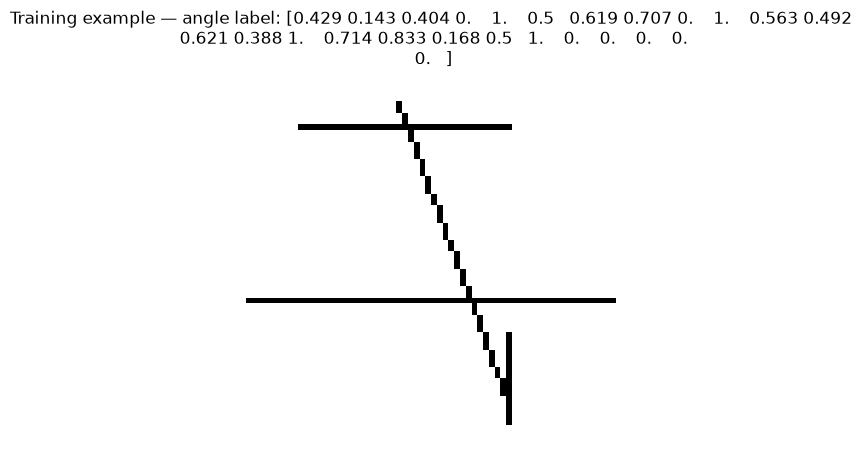

In [5]:
index = 0

plt.imshow(X_train[index].squeeze(), cmap="gray", vmin=0, vmax=1)
plt.title(f"Training example — angle label: {np.round(y_train[index], 3)}")
plt.axis("off")
plt.show()


In [6]:
def build_vector_model():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1), name="raster_input")

    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.Flatten()(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    # Output is [centre_x, centre_y, length, angle, confidence] × MAX_LINES
    # Sigmoid keeps all values between 0 and 1.
    vector_output = layers.Dense(
        MAX_LINES * VALUES_PER_LINE,
        activation="sigmoid",
        name="angle_vector_output"
    )(x)

    return models.Model(inputs=inputs, outputs=vector_output, name="angle_vector_model")


vector_model = build_vector_model()
vector_model.summary()


Model: "angle_vector_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ raster_input (InputLayer)            │ (None, 64, 64, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ angle_vector_output (Dense)          │ (None, 25)                  │           3,225 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,373,785 (9.06 MB)

 Trainable params: 2,373,785 (9.06 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
class DifferentiableAngleLineRasteriser(layers.Layer):
    def __init__(self, img_size=64, sigma=0.018, **kwargs):
        super().__init__(**kwargs)
        self.img_size = img_size
        self.sigma = sigma

        xs = tf.linspace(0.0, 1.0, img_size)
        ys = tf.linspace(0.0, 1.0, img_size)

        grid_x, grid_y = tf.meshgrid(xs, ys)

        self.grid_x = tf.reshape(grid_x, (1, 1, img_size, img_size))
        self.grid_y = tf.reshape(grid_y, (1, 1, img_size, img_size))

    def call(self, vectors):
        vectors = tf.reshape(vectors, (-1, MAX_LINES, VALUES_PER_LINE))

        cx = tf.reshape(vectors[:, :, 0], (-1, MAX_LINES, 1, 1))
        cy = tf.reshape(vectors[:, :, 1], (-1, MAX_LINES, 1, 1))

        # length is stored in 0..1 and expanded to the maximum normalised image diagonal
        length = tf.reshape(vectors[:, :, 2], (-1, MAX_LINES, 1, 1)) * MAX_NORMALISED_LINE_LENGTH

        # angle is stored in 0..1 and expanded to 0..pi radians
        angle = tf.reshape(vectors[:, :, 3], (-1, MAX_LINES, 1, 1)) * np.pi

        confidence = tf.reshape(vectors[:, :, 4], (-1, MAX_LINES, 1, 1))

        half_length = length / 2.0

        dx = tf.cos(angle) * half_length
        dy = tf.sin(angle) * half_length

        x1 = cx - dx
        y1 = cy - dy
        x2 = cx + dx
        y2 = cy + dy

        px = self.grid_x
        py = self.grid_y

        line_dx = x2 - x1
        line_dy = y2 - y1

        length_squared = line_dx * line_dx + line_dy * line_dy + 1e-8

        t = ((px - x1) * line_dx + (py - y1) * line_dy) / length_squared
        t = tf.clip_by_value(t, 0.0, 1.0)

        closest_x = x1 + t * line_dx
        closest_y = y1 + t * line_dy

        distance_squared = tf.square(px - closest_x) + tf.square(py - closest_y)

        line_darkness = tf.exp(
            -distance_squared / (2.0 * self.sigma * self.sigma)
        )

        line_darkness = line_darkness * confidence

        # Combine multiple black lines on a white background
        combined_darkness = 1.0 - tf.reduce_prod(
            1.0 - line_darkness,
            axis=1
        )

        raster = 1.0 - combined_darkness
        raster = tf.expand_dims(raster, axis=-1)

        return raster


In [8]:
def raster_similarity_loss(y_true, y_pred):
    """
    Compare the original raster image with the rasterised vector prediction.

    The images use:
        0 = black line pixel
        1 = white background pixel

    Dice loss focuses on overlap between line pixels.
    MSE keeps the full image close and discourages excessive grey/black pixels.
    """
    true_lines = 1.0 - y_true
    pred_lines = 1.0 - y_pred

    intersection = tf.reduce_sum(true_lines * pred_lines, axis=[1, 2, 3])
    total_line_mass = (
        tf.reduce_sum(true_lines, axis=[1, 2, 3]) +
        tf.reduce_sum(pred_lines, axis=[1, 2, 3])
    )

    dice_loss = 1.0 - ((2.0 * intersection + 1e-6) / (total_line_mass + 1e-6))
    mse_loss = tf.reduce_mean(tf.square(y_true - y_pred), axis=[1, 2, 3])

    return tf.reduce_mean(dice_loss + 0.2 * mse_loss)


In [9]:
raster_output = DifferentiableAngleLineRasteriser(
    img_size=IMG_SIZE,
    sigma=0.010,
    name="raster_output"
)(vector_model.output)

training_model = models.Model(
    inputs=vector_model.input,
    outputs=raster_output,
    name="angle_raster_only_training_model"
)

training_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=raster_similarity_loss,
    metrics=["mae"]
)

early_stop_raster = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_raster = training_model.fit(
    X_train,
    X_train,
    validation_data=(X_test, X_test),
    epochs=RASTER_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop_raster],
    verbose=1
)



Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - loss: 0.9615 - mae: 0.0700 - val_loss: 0.9585 - val_mae: 0.0772
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 0.9604 - mae: 0.0744 - val_loss: 0.9566 - val_mae: 0.0785
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - loss: 0.9583 - mae: 0.0762 - val_loss: 0.9489 - val_mae: 0.0716
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - loss: 0.9462 - mae: 0.0749 - val_loss: 0.9311 - val_mae: 0.0730
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - loss: 0.9341 - mae: 0.0718 - val_loss: 0.9187 - val_mae: 0.0701
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - loss: 0.9265 - mae: 0.0712 - val_loss: 0.9056 - val_mae: 0.0672
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - loss: 0.9207 - mae: 0.0697 - val_loss: 0.8988 - val_mae: 0.0641
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - loss: 0.9168 - mae: 0.0682 - val_loss: 0.8973 - val_mae: 0.0624
Epoch 9/100
313/313 ━━━━━━━━━━━

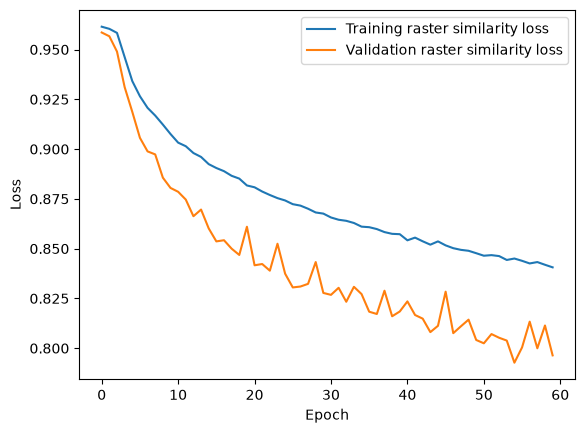

In [10]:
plt.plot(history_raster.history["loss"], label="Training raster similarity loss")
plt.plot(history_raster.history["val_loss"], label="Validation raster similarity loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


Predicted snapped angle lines:
Line 1: centre=(27.8, 36.8), length=22.3, angle=135°, endpoints=(36, 29) to (20, 45), confidence=1.00
Line 2: centre=(32.6, 31.3), length=21.6, angle=132°, endpoints=(40, 23) to (25, 39), confidence=1.00
Line 3: centre=(31.6, 33.1), length=31.4, angle=138°, endpoints=(43, 23) to (20, 44), confidence=1.00
Line 4: centre=(29.9, 34.0), length=38.2, angle=137°, endpoints=(44, 21) to (16, 47), confidence=1.00
Line 5: centre=(35.6, 29.2), length=29.1, angle=133°, endpoints=(45, 19) to (26, 40), confidence=1.00


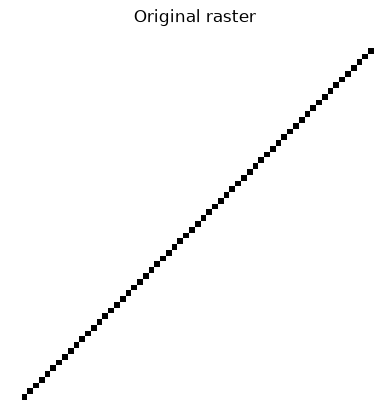

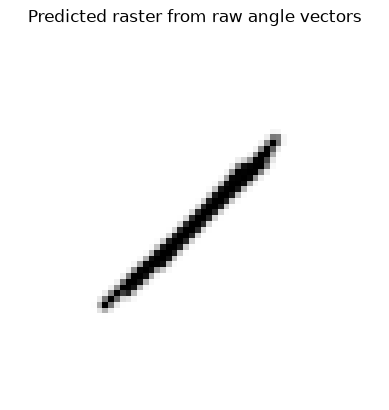

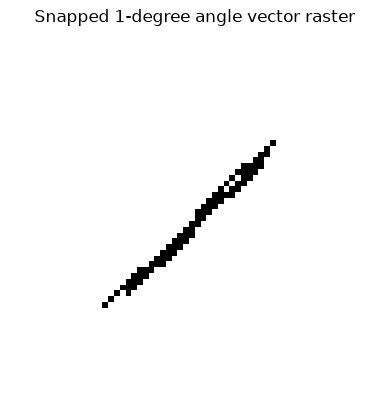

In [11]:
def angle_line_to_endpoints(cx, cy, length, angle_degrees, img_size):
    angle_radians = np.deg2rad(angle_degrees)

    dx = np.cos(angle_radians) * length / 2
    dy = np.sin(angle_radians) * length / 2

    x1 = int(round(cx - dx))
    y1 = int(round(cy - dy))
    x2 = int(round(cx + dx))
    y2 = int(round(cy + dy))

    x1 = int(np.clip(x1, 0, img_size - 1))
    y1 = int(np.clip(y1, 0, img_size - 1))
    x2 = int(np.clip(x2, 0, img_size - 1))
    y2 = int(np.clip(y2, 0, img_size - 1))

    return x1, y1, x2, y2


def decode_angle_vector(vector, img_size=64, confidence_threshold=0.5, snap=True):
    """
    Decode angle-based model output.

    Expected vector shape:
        MAX_LINES * VALUES_PER_LINE

    Each line:
        centre_x, centre_y, length, angle, confidence
    """

    vector = vector.reshape(MAX_LINES, VALUES_PER_LINE)

    decoded_lines = []

    for line in vector:
        cx, cy, length, angle, confidence = line

        if confidence >= confidence_threshold:
            cx = cx * (img_size - 1)
            cy = cy * (img_size - 1)
            length = length * MAX_NORMALISED_LINE_LENGTH * (img_size - 1)
            angle_degrees = (angle * 180.0) % 180.0

            if snap:
                angle_degrees = int(round(angle_degrees)) % 180

            x1, y1, x2, y2 = angle_line_to_endpoints(
                cx,
                cy,
                length,
                angle_degrees,
                img_size
            )

            decoded_lines.append({
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "cx": float(cx),
                "cy": float(cy),
                "length": float(length),
                "angle": angle_degrees,
                "confidence": float(confidence)
            })

    return decoded_lines


def rasterise_decoded_lines(decoded_lines, img_size=64):
    image = Image.new("L", (img_size, img_size), color=255)
    draw = ImageDraw.Draw(image)

    for line in decoded_lines:
        draw.line(
            (line["x1"], line["y1"], line["x2"], line["y2"]),
            fill=0,
            width=LINE_WIDTH
        )

    image_array = np.array(image).astype("float32") / 255.0
    return image_array


sample = X_test[0:1]

predicted_vector = vector_model.predict(sample, verbose=0)[0]
predicted_raster = training_model.predict(sample, verbose=0)[0]

raw_lines = decode_angle_vector(
    predicted_vector,
    img_size=IMG_SIZE,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    snap=False
)

snapped_lines = decode_angle_vector(
    predicted_vector,
    img_size=IMG_SIZE,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    snap=True
)

snapped_raster = rasterise_decoded_lines(snapped_lines, img_size=IMG_SIZE)

print("Predicted snapped angle lines:")

for i, line in enumerate(snapped_lines):
    print(
        f"Line {i + 1}: "
        f"centre=({line['cx']:.1f}, {line['cy']:.1f}), "
        f"length={line['length']:.1f}, "
        f"angle={line['angle']}°, "
        f"endpoints=({line['x1']}, {line['y1']}) to ({line['x2']}, {line['y2']}), "
        f"confidence={line['confidence']:.2f}"
    )

plt.imshow(sample.squeeze(), cmap="gray", interpolation="nearest")
plt.title("Original raster")
plt.axis("off")
plt.show()

plt.imshow(predicted_raster.squeeze(), cmap="gray", interpolation="nearest")
plt.title("Predicted raster from raw angle vectors")
plt.axis("off")
plt.show()

plt.imshow(snapped_raster.squeeze(), cmap="gray", interpolation="nearest")
plt.title("Snapped 1-degree angle vector raster")
plt.axis("off")
plt.show()


Example 0
True angle lines:
  centre=(32.0, 33.0), length=84.9, angle=135°, endpoints=(62, 3) to (2, 63), confidence=1.00
Predicted snapped angle lines:
  centre=(27.8, 36.8), length=22.3, angle=135°, endpoints=(36, 29) to (20, 45), confidence=1.00
  centre=(32.6, 31.3), length=21.6, angle=132°, endpoints=(40, 23) to (25, 39), confidence=1.00
  centre=(31.6, 33.1), length=31.4, angle=138°, endpoints=(43, 23) to (20, 44), confidence=1.00
  centre=(29.9, 34.0), length=38.2, angle=137°, endpoints=(44, 21) to (16, 47), confidence=1.00
  centre=(35.6, 29.2), length=29.1, angle=133°, endpoints=(45, 19) to (26, 40), confidence=1.00


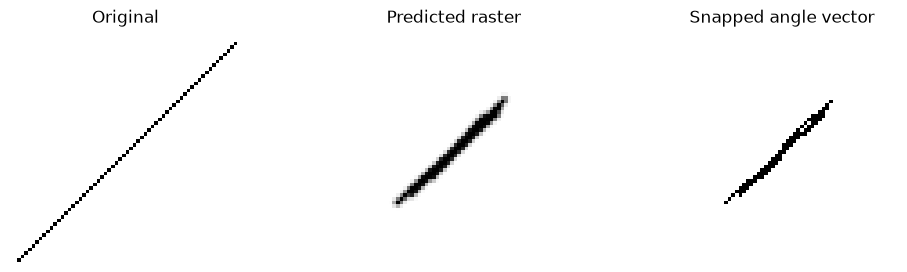

Example 1
True angle lines:
  centre=(20.0, 31.5), length=63.0, angle=90°, endpoints=(20, 0) to (20, 63), confidence=1.00
  centre=(32.0, 29.0), length=76.4, angle=135°, endpoints=(59, 2) to (5, 56), confidence=1.00
  centre=(38.5, 50.0), length=13.0, angle=0°, endpoints=(32, 50) to (45, 50), confidence=1.00
Predicted snapped angle lines:
  centre=(19.8, 33.0), length=41.4, angle=92°, endpoints=(21, 12) to (19, 54), confidence=0.99
  centre=(19.2, 30.8), length=34.1, angle=91°, endpoints=(20, 14) to (19, 48), confidence=0.96
  centre=(19.8, 31.1), length=45.5, angle=90°, endpoints=(20, 8) to (20, 54), confidence=0.99
  centre=(19.6, 34.2), length=44.4, angle=90°, endpoints=(20, 12) to (20, 56), confidence=0.99
  centre=(20.9, 33.3), length=47.7, angle=88°, endpoints=(20, 9) to (22, 57), confidence=0.99


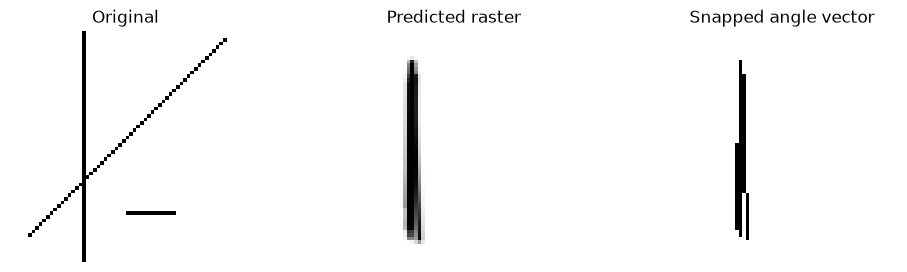

Example 2
True angle lines:
  centre=(43.0, 29.5), length=59.2, angle=60°, endpoints=(28, 4) to (58, 55), confidence=1.00
Predicted snapped angle lines:
  centre=(43.1, 27.7), length=28.4, angle=50°, endpoints=(34, 17) to (52, 39), confidence=1.00
  centre=(45.2, 33.2), length=33.7, angle=55°, endpoints=(36, 19) to (55, 47), confidence=1.00
  centre=(46.4, 32.9), length=27.3, angle=56°, endpoints=(39, 22) to (54, 44), confidence=1.00
  centre=(43.8, 30.4), length=19.2, angle=62°, endpoints=(39, 22) to (48, 39), confidence=1.00
  centre=(47.6, 35.0), length=19.5, angle=72°, endpoints=(45, 26) to (51, 44), confidence=1.00


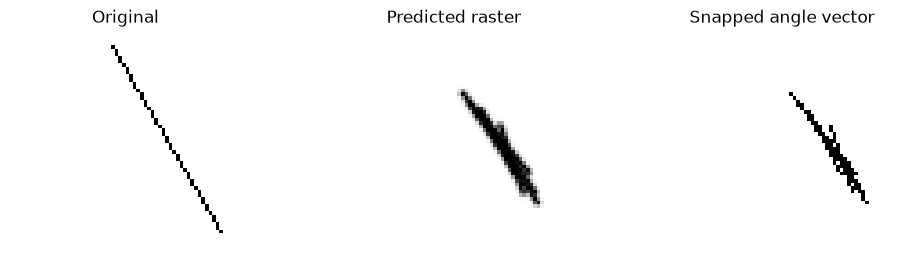

Example 3
True angle lines:
  centre=(42.0, 31.0), length=30.0, angle=90°, endpoints=(42, 16) to (42, 46), confidence=1.00
  centre=(62.0, 35.0), length=24.0, angle=90°, endpoints=(62, 23) to (62, 47), confidence=1.00
Predicted snapped angle lines:
  centre=(42.9, 30.8), length=23.6, angle=90°, endpoints=(43, 19) to (43, 43), confidence=0.98
  centre=(42.5, 29.6), length=27.4, angle=88°, endpoints=(42, 16) to (43, 43), confidence=1.00
  centre=(42.3, 30.2), length=27.5, angle=92°, endpoints=(43, 16) to (42, 44), confidence=0.99
  centre=(42.6, 31.0), length=26.6, angle=92°, endpoints=(43, 18) to (42, 44), confidence=0.99
  centre=(42.6, 31.3), length=28.0, angle=91°, endpoints=(43, 17) to (42, 45), confidence=0.99


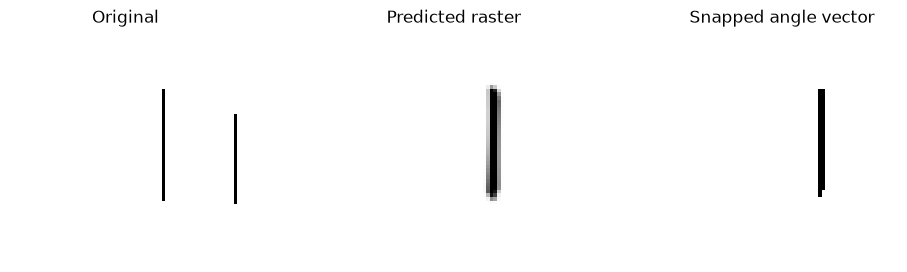

Example 4
True angle lines:
  centre=(11.0, 15.5), length=25.1, angle=95°, endpoints=(12, 3) to (10, 28), confidence=1.00
  centre=(28.5, 4.0), length=49.0, angle=0°, endpoints=(4, 4) to (53, 4), confidence=1.00
  centre=(29.5, 61.0), length=49.0, angle=0°, endpoints=(5, 61) to (54, 61), confidence=1.00
  centre=(34.5, 17.0), length=53.0, angle=0°, endpoints=(8, 17) to (61, 17), confidence=1.00
Predicted snapped angle lines:
  centre=(9.5, 21.4), length=38.8, angle=73°, endpoints=(4, 3) to (15, 40), confidence=1.00
  centre=(12.1, 21.4), length=28.4, angle=66°, endpoints=(6, 8) to (18, 34), confidence=1.00
  centre=(10.7, 21.6), length=38.3, angle=74°, endpoints=(5, 3) to (16, 40), confidence=1.00
  centre=(11.2, 21.3), length=34.3, angle=76°, endpoints=(7, 5) to (15, 38), confidence=1.00
  centre=(13.2, 21.9), length=30.5, angle=81°, endpoints=(11, 7) to (16, 37), confidence=1.00


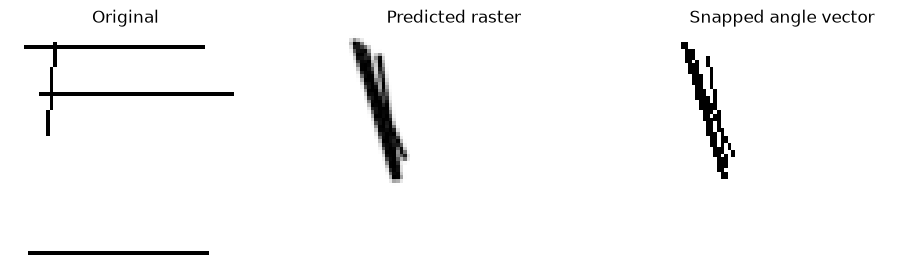

Example 5
True angle lines:
  centre=(12.5, 46.0), length=19.0, angle=0°, endpoints=(3, 46) to (22, 46), confidence=1.00
  centre=(17.0, 23.0), length=20.0, angle=90°, endpoints=(17, 13) to (17, 33), confidence=1.00
  centre=(18.5, 10.0), length=35.8, angle=30°, endpoints=(3, 1) to (34, 19), confidence=1.00
  centre=(29.0, 23.0), length=38.0, angle=0°, endpoints=(10, 23) to (48, 23), confidence=1.00
  centre=(40.0, 31.5), length=39.0, angle=90°, endpoints=(40, 12) to (40, 51), confidence=1.00
Predicted snapped angle lines:
  centre=(40.8, 30.6), length=35.0, angle=91°, endpoints=(41, 13) to (41, 48), confidence=0.94
  centre=(40.4, 31.5), length=38.6, angle=91°, endpoints=(41, 12) to (40, 51), confidence=0.98
  centre=(40.7, 30.4), length=39.8, angle=90°, endpoints=(41, 11) to (41, 50), confidence=0.97
  centre=(40.8, 32.6), length=38.4, angle=89°, endpoints=(40, 13) to (41, 52), confidence=0.97
  centre=(40.1, 32.7), length=42.0, angle=89°, endpoints=(40, 12) to (40, 54), confidence=0

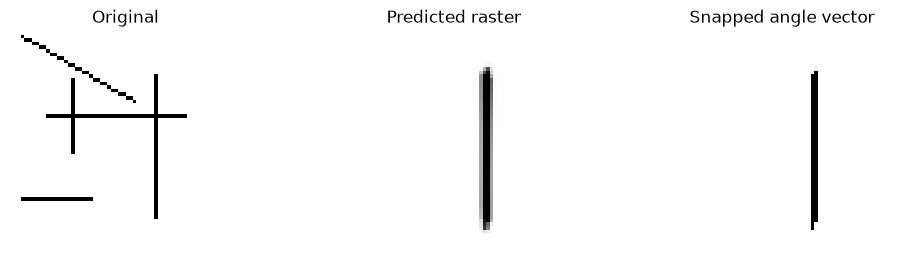

Example 6
True angle lines:
  centre=(31.0, 46.0), length=40.0, angle=0°, endpoints=(11, 46) to (51, 46), confidence=1.00
  centre=(54.0, 37.5), length=33.0, angle=90°, endpoints=(54, 21) to (54, 54), confidence=1.00
Predicted snapped angle lines:
  centre=(52.0, 39.1), length=14.9, angle=101°, endpoints=(53, 32) to (51, 46), confidence=1.00
  centre=(54.6, 37.3), length=22.2, angle=93°, endpoints=(55, 26) to (54, 48), confidence=1.00
  centre=(53.0, 36.4), length=20.2, angle=101°, endpoints=(55, 26) to (51, 46), confidence=1.00
  centre=(52.8, 38.9), length=22.5, angle=114°, endpoints=(57, 29) to (48, 49), confidence=1.00
  centre=(54.0, 39.2), length=26.0, angle=104°, endpoints=(57, 27) to (51, 52), confidence=1.00


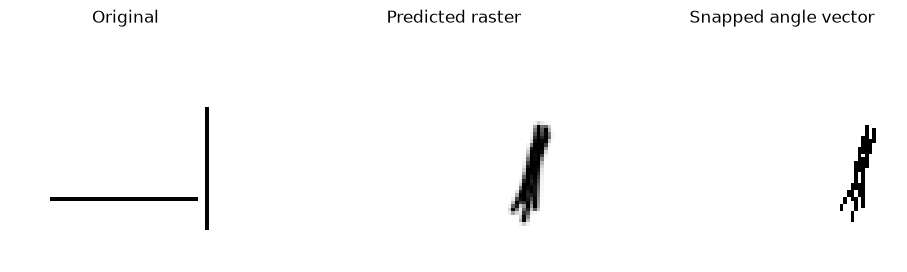

Example 7
True angle lines:
  centre=(26.0, 43.5), length=31.0, angle=90°, endpoints=(26, 28) to (26, 59), confidence=1.00
  centre=(27.5, 42.5), length=46.7, angle=45°, endpoints=(11, 26) to (44, 59), confidence=1.00
  centre=(36.0, 45.0), length=52.0, angle=0°, endpoints=(10, 45) to (62, 45), confidence=1.00
  centre=(44.0, 46.5), length=19.0, angle=90°, endpoints=(44, 37) to (44, 56), confidence=1.00
Predicted snapped angle lines:
  centre=(25.1, 36.6), length=28.2, angle=91°, endpoints=(25, 22) to (25, 51), confidence=0.97
  centre=(26.7, 37.2), length=26.0, angle=90°, endpoints=(27, 24) to (27, 50), confidence=0.95
  centre=(25.1, 35.9), length=28.4, angle=90°, endpoints=(25, 22) to (25, 50), confidence=0.98
  centre=(25.0, 37.3), length=29.4, angle=91°, endpoints=(25, 23) to (25, 52), confidence=0.97
  centre=(25.5, 39.2), length=29.1, angle=91°, endpoints=(26, 25) to (25, 54), confidence=0.98


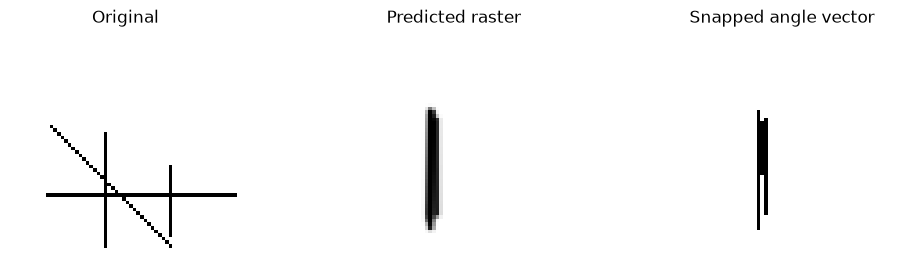

Example 8
True angle lines:
  centre=(14.5, 31.5), length=64.0, angle=80°, endpoints=(9, 0) to (20, 63), confidence=1.00
  centre=(17.0, 30.5), length=57.0, angle=90°, endpoints=(17, 2) to (17, 59), confidence=1.00
  centre=(23.5, 42.0), length=45.0, angle=0°, endpoints=(1, 42) to (46, 42), confidence=1.00
  centre=(28.5, 33.0), length=43.0, angle=0°, endpoints=(7, 33) to (50, 33), confidence=1.00
Predicted snapped angle lines:
  centre=(16.7, 32.4), length=40.1, angle=88°, endpoints=(16, 12) to (17, 52), confidence=1.00
  centre=(15.8, 30.1), length=29.9, angle=85°, endpoints=(14, 15) to (17, 45), confidence=0.98
  centre=(16.7, 30.2), length=43.1, angle=88°, endpoints=(16, 9) to (17, 52), confidence=1.00
  centre=(15.7, 32.3), length=40.6, angle=88°, endpoints=(15, 12) to (16, 53), confidence=1.00
  centre=(17.0, 32.4), length=45.1, angle=86°, endpoints=(15, 10) to (19, 55), confidence=1.00


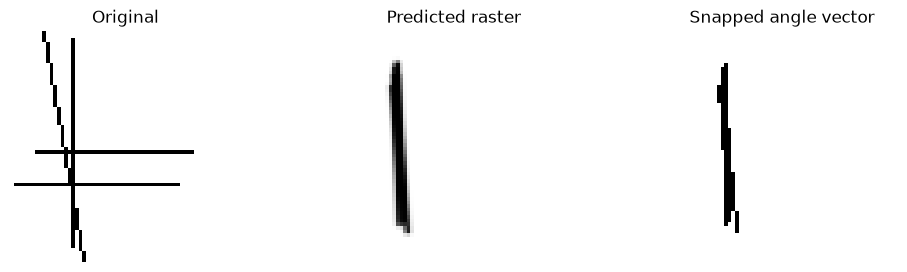

Example 9
True angle lines:
  centre=(15.0, 48.0), length=31.3, angle=117°, endpoints=(22, 34) to (8, 62), confidence=1.00
  centre=(23.5, 45.0), length=19.0, angle=0°, endpoints=(14, 45) to (33, 45), confidence=1.00
  centre=(28.5, 38.0), length=52.0, angle=150°, endpoints=(51, 25) to (6, 51), confidence=1.00
  centre=(42.0, 30.5), length=43.0, angle=90°, endpoints=(42, 9) to (42, 52), confidence=1.00
Predicted snapped angle lines:
  centre=(42.2, 29.7), length=34.2, angle=95°, endpoints=(44, 13) to (41, 47), confidence=0.97
  centre=(41.8, 29.7), length=38.8, angle=90°, endpoints=(42, 10) to (42, 49), confidence=0.99
  centre=(42.2, 28.9), length=38.8, angle=91°, endpoints=(43, 9) to (42, 48), confidence=0.99
  centre=(41.8, 30.4), length=37.7, angle=91°, endpoints=(42, 12) to (41, 49), confidence=0.98
  centre=(42.1, 31.3), length=39.9, angle=90°, endpoints=(42, 11) to (42, 51), confidence=0.99


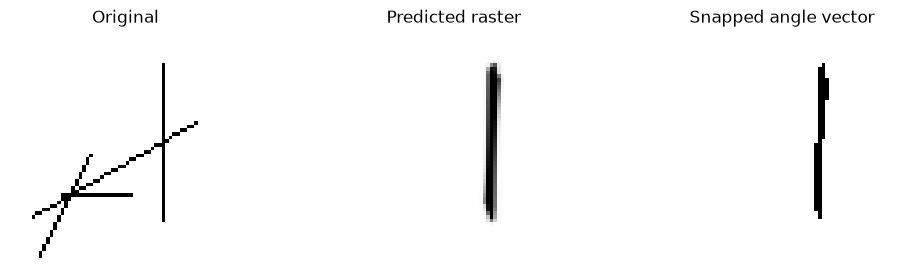

In [12]:
for sample_index in range(10):
    sample = X_test[sample_index:sample_index + 1]
    true_vector = y_test[sample_index]

    predicted_vector = vector_model.predict(sample, verbose=0)[0]
    predicted_raster = training_model.predict(sample, verbose=0)[0]

    true_lines = decode_angle_vector(
        true_vector,
        img_size=IMG_SIZE,
        confidence_threshold=CONFIDENCE_THRESHOLD,
        snap=True
    )

    snapped_lines = decode_angle_vector(
        predicted_vector,
        img_size=IMG_SIZE,
        confidence_threshold=CONFIDENCE_THRESHOLD,
        snap=True
    )

    snapped_raster = rasterise_decoded_lines(snapped_lines, img_size=IMG_SIZE)

    print("Example", sample_index)

    print("True angle lines:")
    for line in true_lines:
        print(
            f"  centre=({line['cx']:.1f}, {line['cy']:.1f}), "
            f"length={line['length']:.1f}, "
            f"angle={line['angle']}°, "
            f"endpoints=({line['x1']}, {line['y1']}) to ({line['x2']}, {line['y2']}), "
            f"confidence={line['confidence']:.2f}"
        )

    print("Predicted snapped angle lines:")
    for line in snapped_lines:
        print(
            f"  centre=({line['cx']:.1f}, {line['cy']:.1f}), "
            f"length={line['length']:.1f}, "
            f"angle={line['angle']}°, "
            f"endpoints=({line['x1']}, {line['y1']}) to ({line['x2']}, {line['y2']}), "
            f"confidence={line['confidence']:.2f}"
        )

    plt.figure(figsize=(12, 3))

    plt.subplot(1, 3, 1)
    plt.imshow(sample.squeeze(), cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(predicted_raster.squeeze(), cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    plt.title("Predicted raster")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(snapped_raster.squeeze(), cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    plt.title("Snapped angle vector")
    plt.axis("off")

    plt.show()
